In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('Anime.csv')

In [6]:
df.head()

,Rank,Name,Japanese_name,Type,Episodes,Studio,Release_season,Tags,Rating,Release_year,End_year,Description,Content_Warning,Related_Mange,Related_anime,Voice_actors,staff
0,1,Demon Slayer: Kimetsu no Yaiba - Entertainment...,Kimetsu no Yaiba: Yuukaku-hen,TV,NaN,ufotable,Fall,"Action, Adventure, Fantasy, Shounen, Demons, H...",4.60,2021.0,NaN,'Tanjiro and his friends accompany the Hashira...,Explicit Violence,Demon Slayer: Kimetsu no Yaiba,"Demon Slayer: Kimetsu no Yaiba, Demon Slayer: ...","Inosuke Hashibira : Yoshitsugu Matsuoka, Nezuk...","Koyoharu Gotouge : Original Creator, Haruo Sot..."
1,2,Fruits Basket the Final Season,Fruits Basket the Final,TV,13.0,TMS Entertainment,Spring,"Drama, Fantasy, Romance, Shoujo, Animal Transf...",4.60,2021.0,NaN,'The final arc of Fruits Basket.',"Emotional Abuse,, Mature Themes,, Physical Abu...","Fruits Basket, Fruits Basket Another","Fruits Basket 1st Season, Fruits Basket 2nd Se...","Akito Sohma : Maaya Sakamoto, Kyo Sohma : Yuum...","Natsuki Takaya : Original Creator, Yoshihide I..."
2,3,Mo Dao Zu Shi 3,The Founder of Diabolism 3,Web,12.0,B.C MAY PICTURES,NaN,"Fantasy, Ancient China, Chinese Animation, Cul...",4.58,2021.0,NaN,'The third season of Mo Dao Zu Shi.',NaN,Grandmaster of Demonic Cultivation: Mo Dao Zu ...,"Mo Dao Zu Shi 2, Mo Dao Zu Shi Q","Lan Wangji, Wei Wuxian, Jiang Cheng, Jin Guang...","Mo Xiang Tong Xiu : Original Creator, Xiong Ke..."
3,4,Fullmetal Alchemist: Brotherhood,Hagane no Renkinjutsushi: Full Metal Alchemist,TV,64.0,Bones,Spring,"Action, Adventure, Drama, Fantasy, Mystery, Sh...",4.58,2009.0,2010.0,"""The foundation of alchemy is based on the law...","Animal Abuse,, Mature Themes,, Violence,, Dome...","Fullmetal Alchemist, Fullmetal Alchemist (Ligh...","Fullmetal Alchemist: Brotherhood Specials, Ful...","Alphonse Elric : Rie Kugimiya, Edward Elric : ...","Hiromu Arakawa : Original Creator, Yasuhiro Ir..."
4,5,Attack on Titan 3rd Season: Part II,Shingeki no Kyojin Season 3: Part II,TV,10.0,WIT Studio,Spring,"Action, Fantasy, Horror, Shounen, Dark Fantasy...",4.57,2019.0,NaN,'The battle to retake Wall Maria begins now! W...,"Cannibalism,, Explicit Violence","Attack on Titan, Attack on Titan: End of the W...","Attack on Titan, Attack on Titan 2nd Season, A...","Armin Arlelt : Marina Inoue, Eren Jaeger : Yuu...","Hajime Isayama : Original Creator, Tetsurou Ar..."


In [7]:
df.columns

Index(['Rank', 'Name', 'Japanese_name', 'Type', 'Episodes', 'Studio',
       'Release_season', 'Tags', 'Rating', 'Release_year', 'End_year',
       'Description', 'Content_Warning', 'Related_Mange', 'Related_anime',
       'Voice_actors', 'staff'],
      dtype='object')

In [8]:
df = df[[ 'Type', 'Episodes','Tags','Rating', 'Release_year']]
df.head()

,Type,Episodes,Tags,Rating,Release_year
0,TV,NaN,"Action, Adventure, Fantasy, Shounen, Demons, H...",4.60,2021.0
1,TV,13.0,"Drama, Fantasy, Romance, Shoujo, Animal Transf...",4.60,2021.0
2,Web,12.0,"Fantasy, Ancient China, Chinese Animation, Cul...",4.58,2021.0
3,TV,64.0,"Action, Adventure, Drama, Fantasy, Mystery, Sh...",4.58,2009.0
4,TV,10.0,"Action, Fantasy, Horror, Shounen, Dark Fantasy...",4.57,2019.0


In [9]:
df.isnull().sum()

Type               0
Episodes        8994
Tags             400
Rating          3131
Release_year     383
dtype: int64

In [10]:
df.duplicated().sum()                                                                                            

np.int64(588)

In [11]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17907 entries, 0 to 18494
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Type          17907 non-null  object 
 1   Episodes      9387 non-null   float64
 2   Tags          17575 non-null  object 
 3   Rating        15142 non-null  float64
 4   Release_year  17551 non-null  float64
dtypes: float64(3), object(2)
memory usage: 839.4+ KB


In [13]:
df.describe()

,Episodes,Rating,Release_year
count,9387.000000,15142.000000,17551.000000
mean,20.832428,3.356918,2006.617800
std,37.939486,0.402572,14.902296
min,1.000000,0.960000,1907.000000
25%,2.000000,3.130000,2001.000000
50%,12.000000,3.360000,2012.000000
75%,26.000000,3.590000,2017.000000
max,800.000000,4.600000,2023.000000


# EDA 

# 1. Missing Values Bar Chart

<Axes: xlabel='None'>

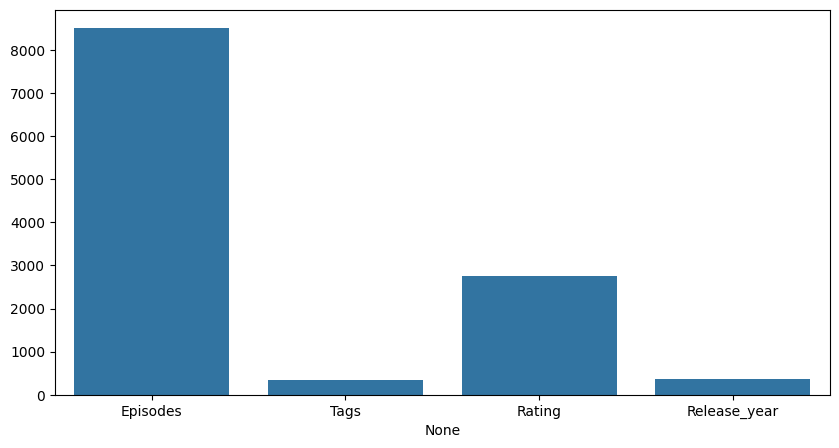

In [14]:
missing = df.isnull().sum()
missing = missing[missing>0]
plt.figure(figsize=(10,5))
sns.barplot(x = missing.index , y = missing.values)

# Handling Missing values

In [15]:
df.isnull().mean()

Type            0.000000
Episodes        0.475792
Tags            0.018540
Rating          0.154409
Release_year    0.019880
dtype: float64

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer


In [17]:
X = df.drop(columns = ["Type"])
y = df['Type']

In [18]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2, stratify=y,random_state = 2)

In [19]:
X_train.shape,X_test.shape

((14325, 4), (3582, 4))

In [20]:
X_train.isnull().mean()

Episodes        0.474346
Tags            0.018360
Rating          0.152949
Release_year    0.019197
dtype: float64

In [21]:
X_test.isnull().mean()

Episodes        0.481575
Tags            0.019263
Rating          0.160246
Release_year    0.022613
dtype: float64

### Numerical

In [22]:
med_epi = X_train['Episodes'].median()
med_rating = X_train['Rating'].median()
med_rel = X_train['Release_year'].median()

In [23]:
print("Original Episodes variable variance : ",X_train['Episodes'].var())
print("Original Rating variable variance : ",X_train['Rating'].var())
print("Original Release year variable variance : ",X_train['Release_year'].var())

Original Episodes variable variance :  1507.7400052422347
Original Rating variable variance :  0.1622948185391968
Original Release year variable variance :  225.8092946623805


In [24]:
X_train['Episodes'] = X_train['Episodes'].fillna(med_epi)
X_train['Rating'] = X_train['Rating'].fillna(med_rating)
X_train['Release_year'] = X_train['Release_year'].fillna(med_rel)
X_test['Episodes'] = X_test['Episodes'].fillna(med_epi)
X_test['Rating'] = X_test['Rating'].fillna(med_rating)
X_test['Release_year'] = X_test['Release_year'].fillna(med_rel)

In [25]:
X_test.isnull().mean()

Episodes        0.000000
Tags            0.019263
Rating          0.000000
Release_year    0.000000
dtype: float64

In [26]:
X_test.isnull().sum()

Episodes         0
Tags            69
Rating           0
Release_year     0
dtype: int64

In [27]:
X_train.isnull().sum()

Episodes          0
Tags            263
Rating            0
Release_year      0
dtype: int64

In [28]:
print("New Episodes variable variance : ",X_train['Episodes'].var())
print("New Rating variable variance : ",X_train['Rating'].var())
print("New Release year variable variance : ",X_train['Release_year'].var())

New Episodes variable variance :  812.8495031028273
New Rating variable variance :  0.13747133332358918
New Release year variable variance :  222.03026733590576


### Categorical

In [29]:
imputer = SimpleImputer(strategy = 'constant',fill_value = "Missing")
X_train['Tags'] = imputer.fit_transform(X_train[['Tags']]).ravel()
X_test['Tags'] = imputer.transform(X_test[['Tags']]).ravel()

In [30]:
X_train.isnull().mean()

Episodes        0.0
Tags            0.0
Rating          0.0
Release_year    0.0
dtype: float64

In [31]:
X_test.isnull().mean()

Episodes        0.0
Tags            0.0
Rating          0.0
Release_year    0.0
dtype: float64

# 2. Target Variable Distribution

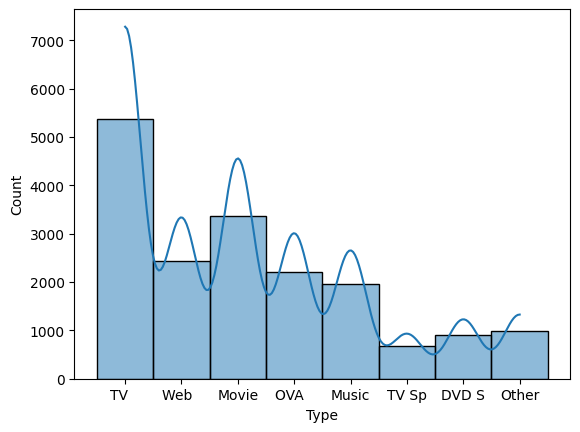

In [32]:
sns.histplot(y, kde= True)
plt.show()

# 3. Checking whether outliers exist or not

[]

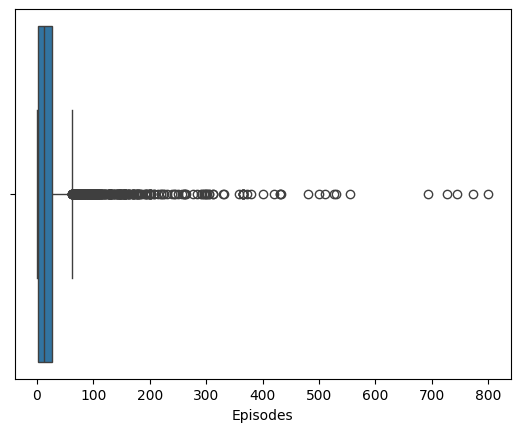

In [33]:
sns.boxplot(x = 'Episodes',data = df)
plt.plot()

[]

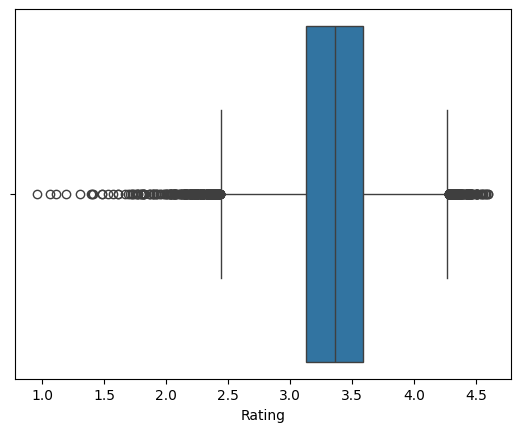

In [34]:
sns.boxplot(x = 'Rating',data = df)
plt.plot()

[]

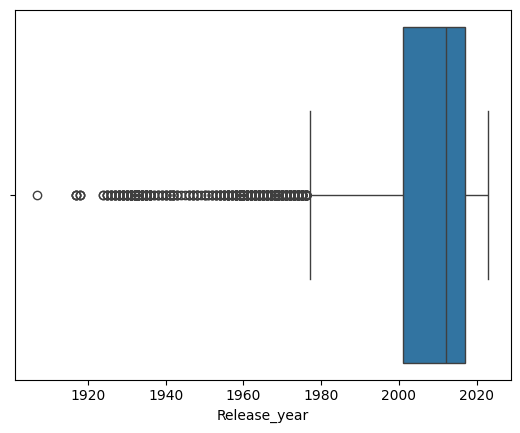

In [377]:
sns.boxplot(x = 'Release_year',data = df)
plt.plot()

# Correlation 

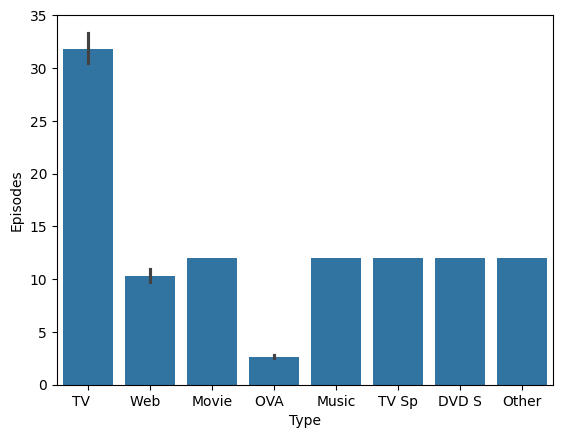

In [90]:
sns.barplot(x = y,y =X_train['Episodes'] )

plt.show()

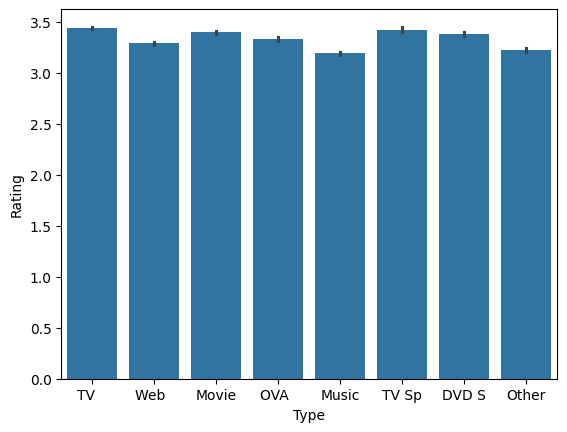

In [378]:
sns.barplot(x = y,y =X_train['Rating'] )

plt.show()

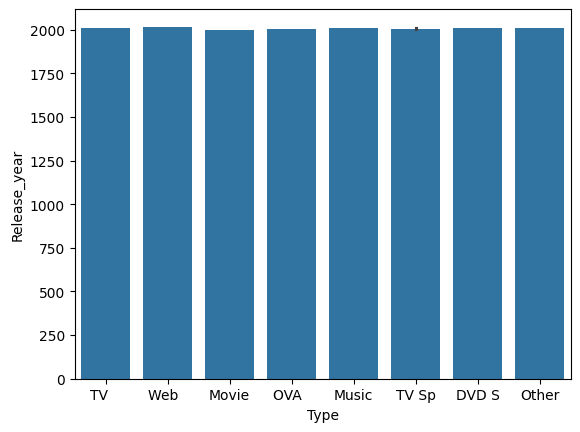

In [35]:
sns.barplot(x = y,y =X_train['Release_year'] )

plt.show()

# Encoding

In [36]:
# Double check the column exists, then encode safely
X_train = pd.get_dummies(X_train, columns=['Tags'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['Tags'], drop_first=True)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [37]:
print(X_train.shape)
print(X_test.shape)

(14325, 9774)
(3582, 9774)


In [38]:
print(X_train)

       Episodes  Rating  Release_year  \
10351      12.0    3.20        2002.0   
12949       1.0    3.00        2015.0   
14004      12.0    2.84        2012.0   
18218      24.0    3.36        2021.0   
5649       12.0    3.47        2018.0   
...         ...     ...           ...   
17496       2.0    3.36        2012.0   
14212      12.0    2.79        2019.0   
7369       12.0    3.37        2003.0   
920        12.0    3.99        2021.0   
5915        1.0    3.45        1995.0   

       Tags_19th Century, America, Countryside, Family Friendly, Historical, Orphans, World Masterpiece Theater, Based on a Novel  \
10351                                              False                                                                            
12949                                              False                                                                            
14004                                              False                                                    

In [39]:
from sklearn.preprocessing import LabelEncoder

# 1. Encode targets from strings to integers
le = LabelEncoder()
y_train_new = le.fit_transform(y_train.astype(str))
y_test_new = le.transform(y_test.astype(str))


# Model Training

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

#Scaling
numeric_cols = ['Episodes', 'Rating', 'Release_year']
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])


model = LogisticRegression(max_iter = 1000)
model.fit(X_train,y_train_new)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [41]:
y_pred = model.predict(X_test)

In [42]:
from sklearn.metrics import accuracy_score, mean_absolute_error
print(accuracy_score(y_test_new,y_pred))

0.615857063093244


In [43]:
mean_absolute_error(y_test_new,y_pred)

1.2643774427694026

In [68]:
from sklearn.ensemble import RandomForestClassifier
mod = RandomForestClassifiermodel = RandomForestClassifier(
    n_estimators=100,
    max_depth=9,         
    random_state=42)

mod.fit(X_train, y_train_new)

,n_estimators,100
,criterion,'gini'
,max_depth,9
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [69]:
y_prede = mod.predict(X_test)
print(accuracy_score(y_test_new,y_prede))

0.30513679508654384


In [70]:
y_prede_train = mod.predict(X_train)
print(accuracy_score(y_train_new,y_prede_train))

0.3056195462478185


In [67]:
import joblib
joblib.dump(model,'anime1.pkl')
joblib.dump(mod,'animee.pkl')

['animee.pkl']